In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

In [2]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['PRICE'] = housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


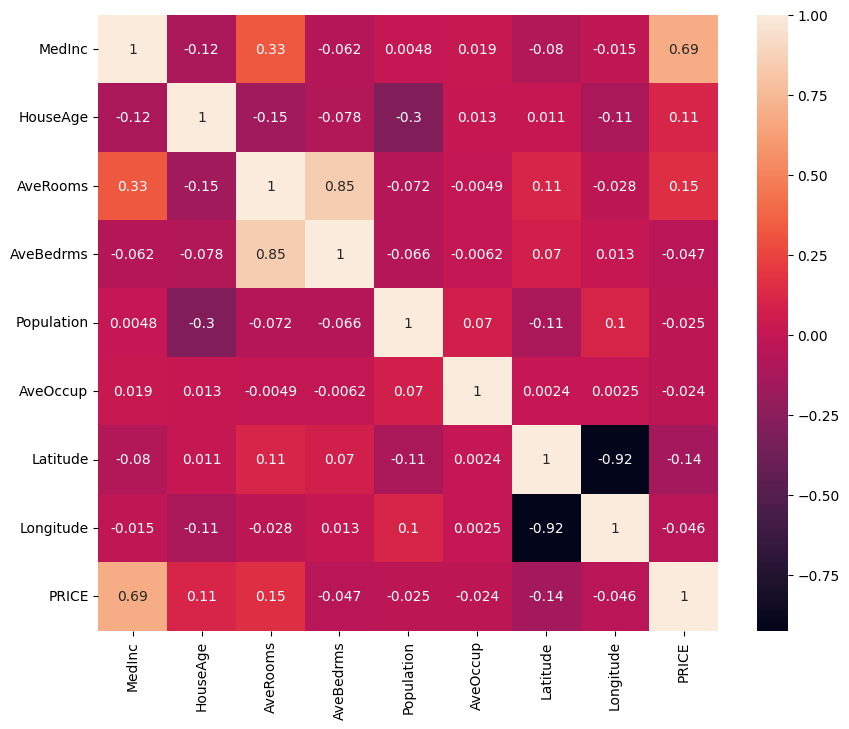

In [4]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [5]:
X = df.drop('PRICE', axis=1)
y = df['PRICE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

print('Train Score:', lr.score(X_train, y_train))
print('Test Score:', lr.score(X_test, y_test))

Train Score: 0.609345972797216
Test Score: 0.5957702326061665


In [7]:
ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)

print('Train Score:', ridge.score(X_train, y_train))
print('Test Score:', ridge.score(X_test, y_test))

Train Score: 0.609337855666805
Test Score: 0.5962256382677007


In [8]:

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

print('Train Score:', lasso.score(X_train, y_train))
print('Test Score:', lasso.score(X_test, y_test))

Train Score: 0.5461181785194866
Test Score: 0.545117728367666


In [9]:
# Create coefficient comparison table
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Linear": lr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

# Set feature as index (optional, cleaner view)
coef_df.set_index("Feature", inplace=True)

# Display table
coef_df

,Linear,Ridge,Lasso
Feature,,,
MedInc,4.458226e-01,4.440416e-01,0.390945
HouseAge,9.681868e-03,9.702193e-03,0.015060
AveRooms,-1.220951e-01,-1.187074e-01,-0.000000
AveBedrms,7.785996e-01,7.597313e-01,0.000000
Population,-7.757404e-07,-7.225786e-07,0.000018
AveOccup,-3.370027e-03,-3.364839e-03,-0.003065
Latitude,-4.185367e-01,-4.184445e-01,-0.115484
Longitude,-4.336880e-01,-4.333529e-01,-0.101649


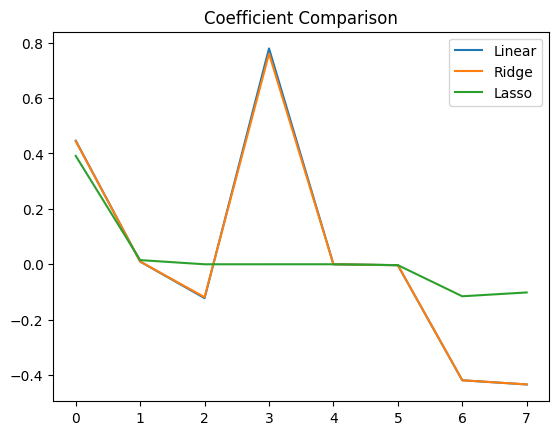

In [10]:
# Compare coefficients
plt.figure()
plt.plot(lr.coef_, label='Linear')
plt.plot(ridge.coef_, label='Ridge')
plt.plot(lasso.coef_, label='Lasso')
plt.legend()
plt.title('Coefficient Comparison')
plt.show()